In [1]:
import hoda
import tensorly as tl
import mne

!pip install line_profiler
%load_ext line_profiler

mne.set_log_level('ERROR')
tl.get_backend()


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5

fmax = 16
sfreq = 64

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014009()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[3],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

BNCI2014009 has been renamed to BNCI2014_009. BNCI2014009 will be removed in version 1.1.
The dataset class name 'BNCI2014009' must be an abbreviation of its code 'BNCI2014-009'. See moabb.datasets.base.is_abbrev for more information.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
meta

,subject,session,run
0,3,0,0
1,3,0,0
2,3,0,0
3,3,0,0
4,3,0,0
...,...,...,...
571,3,0,0
572,3,0,0
573,3,0,0
574,3,0,0


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = epochs.get_data()
y = labels

X.shape

(576, 16, 52)

In [6]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter


bttda = BTTDA(
    ranks=[
(1, 1),
(8, 8),
(1, 1),
(2, 2),
(2, 2),
(2, 2),
(2, 2),
(1, 1),
    ],
    hoda_params=dict(
        max_iter=256,
        tol=1e-12,
        init ='svd',
        shrinkage=0,
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=True,
       
    ),
    verbose=True,
    extra_train_info=True,
)
#%env PYTHONWARNINGS=ignore
bttda.fit(X,y)

Fitting block 1/8...
Fitting discriminative tensor model of rank (1, 1)...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitting block 2/8...
Fitting discriminative tensor model of rank (8, 8)...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitting block 3/8...
Fitting discriminative tensor model of rank (1, 1)...


...

Fitting block 7/8...
Fitting discriminative tensor model of rank (2, 2)...


  0%|          | 0/256 [00:00<?, ?it/s]

Fitting block 8/8...
Fitting discriminative tensor model of rank (1, 1)...


  0%|          | 0/256 [00:00<?, ?it/s]

BTTDA(extra_train_info=True,
      hoda_params={'extra_train_info': False, 'init': 'svd', 'max_iter': 256,
                   'obj': 'rt', 'rank': (1, 1), 'shrinkage': 0,
                   'solver': 'lanczos', 'taper': False, 'toeplitz': None,
                   'tol': 1e-12, 'verbose': True},
      ranks=[(1, 1), (8, 8), (1, 1), (2, 2), (2, 2), (2, 2), (2, 2), (1, 1)],
      verbose=True)

In [7]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df

,block,rank,F_tr,F_rt,mse
0,1,"(1, 1)",0.860834,0.002989,0.981185
1,2,"(8, 8)",0.092697,0.006033,0.851172
2,3,"(1, 1)",0.094129,0.006664,0.848374
3,4,"(2, 2)",0.095199,0.007455,0.847324
4,5,"(2, 2)",0.095463,0.008432,0.844219
5,6,"(2, 2)",0.095594,0.008753,0.842772
6,7,"(2, 2)",0.095594,0.008798,0.842771
7,8,"(1, 1)",0.095594,0.008808,0.842778


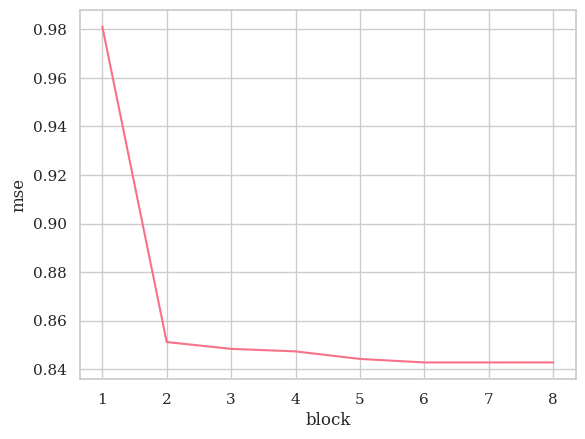

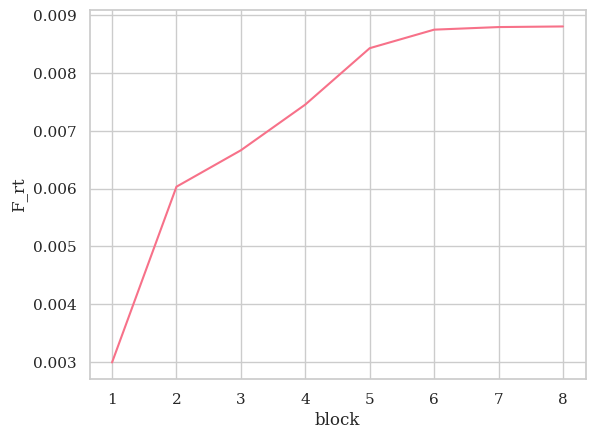

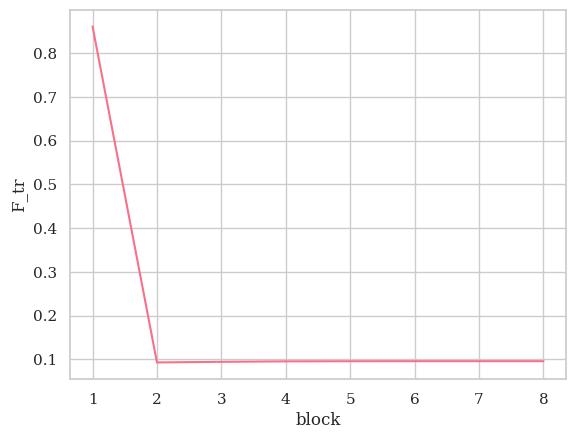

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

if bttda.extra_train_info:
    n_samples = X.shape[0]
    sns.lineplot(data=df, x='block', y='mse')
    plt.show()
    sns.lineplot(data=df,x='block',y='F_rt')
    plt.show()
    sns.lineplot(data=df,x='block',y='F_tr')

In [9]:
Xt = bttda.transform(X)

(1, 1)
(8, 8)
(1, 1)
(2, 2)
(2, 2)
(2, 2)
(2, 2)
(1, 1)


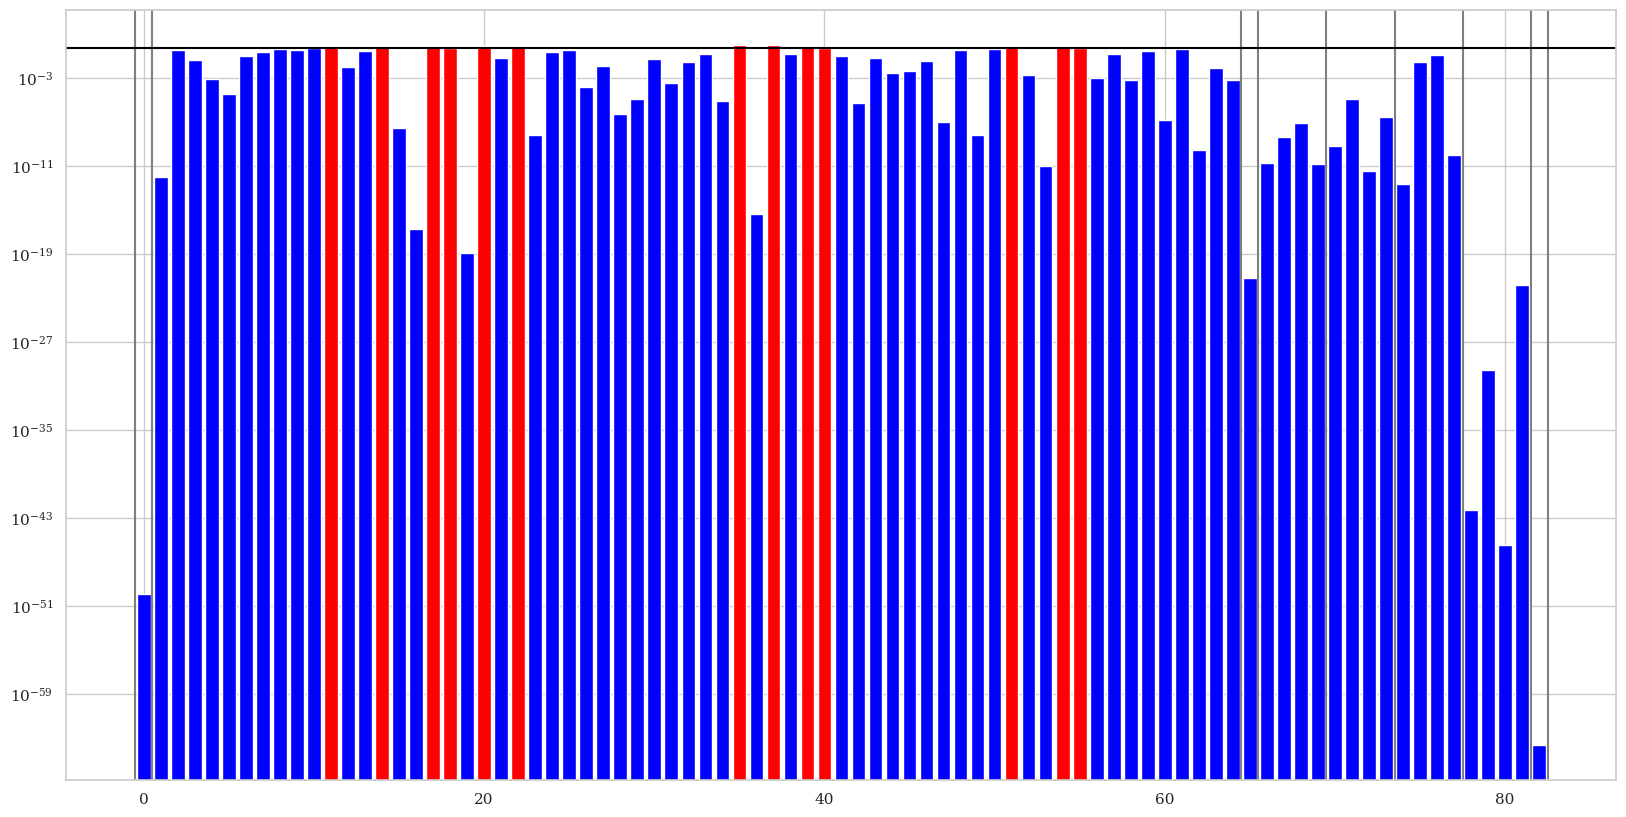

In [10]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)

alpha=0.5
sig_idc = p < alpha

fig, ax = plt.subplots(1,1, figsize=(20,10))
ax.bar(np.arange(len(F))[sig_idc],p[sig_idc], color='blue')
ax.bar(np.arange(len(F))[~sig_idc],p[~sig_idc], color='red')
ax.set_yscale('log')
n_params=0
ax.axvline(n_params-.5, color='grey')
for b in bttda.blocks_:
    n_params+=math.prod(b.rank_)
    print(b.rank_)
    ax.axvline(n_params-.5, color='grey')
ax.axhline(alpha, color='black')

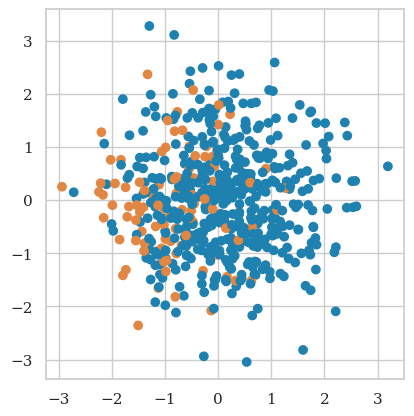

In [11]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt[:,sig_idc]))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


In [ ]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]),units=dict(eeg=None))
joint_args=dict(ts_args=ts_args)

In [ ]:
from mne import combine_evoked

image_kwargs=dict(vmin=-10, vmax=10,picks=['Cz'], sigma=2)

err = tl.tensor(X.copy())
err_epochs = epochs.copy()
err_epochs._data = tl.to_numpy(err)
err_target = err_epochs['Target'].average()
err_non_target=err_epochs['NonTarget'].average()
err_contrast = combine_evoked([err_target,err_non_target], weights=[1,-1])
#err_contrast.plot_joint(**joint_args)
err_epochs['Target'][:100].plot_image(**image_kwargs)
for block in bttda.blocks_[:10]:
    err = block.inv_transform(block.transform(err))
    err_epochs = epochs.copy()
    err_epochs._data = tl.to_numpy(err)
    err_target = err_epochs['Target'].average()
    err_non_target=err_epochs['NonTarget'].average()
    err_contrast = combine_evoked([err_target,err_non_target], weights=[1,-1])
    #err_contrast.plot_joint(**joint_args)
    err_epochs['Target'][:100].plot_image(**image_kwargs)


In [ ]:
from mne import EvokedArray

for b in bttda.blocks_[:10]:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)



In [ ]:
X_rec = bttda.inv_transform(Xt)
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(X_rec)
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls,**joint_args)
    else:
        evoked_rec.plot(**ts_args)

In [ ]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


In [ ]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)